In [ ]:
"""
OBO Ontology Graph Parser adapted for Google Colab.

This script parses OBO files and extracts the ontology graph structure,
focusing on 'is_a' relationships to build parent-child hierarchies.

Usage in Colab:
1. Upload your OBO file (e.g., 'cl.obo') to your Colab environment.
   You can do this by clicking the folder icon on the left sidebar ->
   'Files' tab -> 'Upload to session storage'.
2. Run the `main` function with your input OBO file name and desired output JSON file name.
   Example: main('cl.obo', 'cl_graph.json')
"""

import re
import json
from pathlib import Path
from typing import Dict, List, Set


class OBOGraphParser:
    """Parser for OBO ontology graph structure."""

    def __init__(self):
        self.terms: Dict[str, Dict] = {}
        self.graph: Dict[str, List[str]] = {}  # term_id -> [parent_ids]
        self.stats = {
            'total_terms': 0,
            'terms_with_parents': 0,
            'total_relationships': 0
        }
        self.hra_terms: Set[str] = set()  # Track subset terms
    


    def parse_file(self, filepath: str) -> None:
        """Parse an OBO file and extract graph structure."""
        print(f"Processing {filepath}...")

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()
        except FileNotFoundError:
            print(f"Error: File not found at {filepath}. Please ensure the file is uploaded or the path is correct.")
            return
        except Exception as e:
            print(f"Error reading file {filepath}: {e}")
            return

        # Split into term blocks
        blocks = self._split_into_blocks(content)

        for block in blocks:
            if not block.strip():
                continue

            lines = [line.strip() for line in block.strip().split('\n')]
            if not lines:
                continue

            # Check if the block starts with a valid block type, e.g., [Term]
            if not lines[0].startswith('[') or not lines[0].endswith(']'):
                continue # Skip malformed blocks

            block_type = lines[0].strip('[]')

            if block_type == 'Term':
                self._parse_term_block(lines[1:])
            
            # After parsing, restrict to HRA terms + ancestors
        if self.hra_terms:
            keep_terms = set()

            def collect_ancestors(term_id: str):
                if term_id in keep_terms:
                    return
                keep_terms.add(term_id)
                for parent in self.graph.get(term_id, []):
                    collect_ancestors(parent)

            for hra_term in self.hra_terms:
                collect_ancestors(hra_term)

            # Filter terms and graph
            self.terms = {tid: self.terms[tid] for tid in keep_terms if tid in self.terms}
            self.graph = {tid: self.graph[tid] for tid in keep_terms if tid in self.graph}

            # Update stats
            self.stats['total_terms'] = len(self.terms)
            self.stats['terms_with_parents'] = sum(1 for t in self.terms.values() if t['parents'])
            self.stats['total_relationships'] = sum(len(t['parents']) for t in self.terms.values())



        print(f"✓ Successfully processed {filepath}")

    def _split_into_blocks(self, content: str) -> List[str]:
        """Split OBO content into blocks based on [Term], [Typedef], etc."""
        # This regex looks for lines starting with '[', followed by one or more
        # characters that are not ']', and ending with ']', followed by a newline.
        # It then splits the content based on these block headers.
        block_pattern = re.compile(r'^\[[^\]]+\]\n', re.MULTILINE)

        # Find all block headers and their positions
        matches = list(block_pattern.finditer(content))

        if not matches:
            # If no explicit blocks are found, treat the whole content as one block
            return [content]

        blocks = []
        for i, match in enumerate(matches):
            start = match.start()
            # The end of the current block is the start of the next block,
            # or the end of the content if it's the last block.
            end = matches[i + 1].start() if i + 1 < len(matches) else len(content)
            blocks.append(content[start:end])

        return blocks

    def _parse_term_block(self, lines: List[str]) -> None:
            """Parse a [Term] block and extract term info and relationships."""
            term_id = None
            name = ""
            parents = []
            is_obsolete = False
            in_hra_subset = False

            for line in lines:
                if not line or line.startswith('!'):
                    continue
                if ':' not in line:
                    continue

                key, value = line.split(':', 1)
                key = key.strip()
                value = value.strip()

                if key == 'id':
                    term_id = value
                elif key == 'name':
                    name = value
                elif key == 'is_a':
                    parent_match = re.match(r'([A-Z_]+:\d+)', value)
                    if parent_match:
                        parents.append(parent_match.group(1))
                elif key == 'is_obsolete':
                    is_obsolete = value.lower() == 'true'
                elif key == 'subset' and value == 'human_reference_atlas':
                    in_hra_subset = True

            # Save all terms (for ancestor tracking), even if not in subset
            if term_id and not is_obsolete:
                self.terms[term_id] = {
                    'name': name,
                    'parents': parents
                }
                self.graph[term_id] = parents

                if in_hra_subset:
                    self.hra_terms.add(term_id)

    def save_graph(self, output_file: str) -> None:
        """Save the ontology graph to a JSON file."""
        graph_data = {
            'metadata': {
                'total_terms': self.stats['total_terms'],
                'terms_with_parents': self.stats['terms_with_parents'],
                'total_relationships': self.stats['total_relationships']
            },
            'terms': self.terms,
            'graph': self.graph
        }

        try:
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(graph_data, f, indent=2, ensure_ascii=False)

            print(f"\n✓ Successfully saved ontology graph to {output_file}")
            self._print_stats()

        except Exception as e:
            print(f"✗ Error saving graph file: {e}")

    def _print_stats(self) -> None:
        """Print processing statistics."""
        print(f"\nProcessing Statistics:")
        print(f"  Total terms: {self.stats['total_terms']}")
        print(f"  Terms with parents: {self.stats['terms_with_parents']}")
        print(f"  Total is_a relationships: {self.stats['total_relationships']}")

    def print_sample_hierarchy(self, n: int = 5) -> None:
        """Print a sample of the hierarchy structure."""
        print(f"\nSample hierarchy (first {n} terms):")
        count = 0
        for term_id, term_data in self.terms.items():
            if count >= n:
                break

            print(f"  {term_id}: {term_data['name']}")
            if term_data['parents']:
                for parent_id in term_data['parents']:
                    parent_name = self.terms.get(parent_id, {}).get('name', 'Unknown')
                    print(f"    ↳ is_a: {parent_id} ({parent_name})")
            else:
                print(f"    ↳ (root term or no 'is_a' parents found)")
            print()
            count += 1

    def find_roots(self) -> List[str]:
        """Find root terms (terms with no 'is_a' parents)."""
        roots = []
        for term_id, parents in self.graph.items():
            if not parents: # A term is a root if it has no 'is_a' parents in the parsed graph
                roots.append(term_id)
        return roots

    def find_leaves(self) -> List[str]:
        """Find leaf terms (terms that are not 'is_a' parents of any other term)."""
        all_parents_in_graph = set()
        for parents_list in self.graph.values():
            all_parents_in_graph.update(parents_list)

        leaves = []
        for term_id in self.graph.keys():
            # A term is a leaf if it exists in the graph but is not listed as a parent for any other term
            if term_id not in all_parents_in_graph:
                leaves.append(term_id)
        return leaves


def main(obo_file_path: str, output_json_path: str, sample_terms_to_display: int = 50):
    """
    Main function to parse an OBO file and save its graph structure.
    Designed for use in Google Colab.

    Args:
        obo_file_path (str): The path to the input OBO file.
        output_json_path (str): The desired path for the output JSON file.
        sample_terms_to_display (int): Number of sample terms to display in the output.
    """
    try:
        parser_obj = OBOGraphParser()

        # Process the input file
        parser_obj.parse_file(obo_file_path)

        if not parser_obj.terms:
            print("No terms found in the input file or parsing failed.")
            return

        # Show sample hierarchy
        parser_obj.print_sample_hierarchy(sample_terms_to_display)

        # Find and display roots and leaves
        roots = parser_obj.find_roots()
        leaves = parser_obj.find_leaves()

        print(f"\nGraph Analysis:")
        print(f"  Root terms (no 'is_a' parents in the parsed graph): {len(roots)}")
        print(f"  Leaf terms (no 'is_a' children in the parsed graph): {len(leaves)}")

        # Save the graph
        parser_obj.save_graph(output_json_path)

        print(f"\n✓ Graph parsing complete! Output saved to: {output_json_path}")

        
    except Exception as e:
        print(f"✗ An unexpected error occurred: {e}")


In [22]:
# !wget https://purl.obolibrary.org/obo/uberon/uberon-basic.obo

In [23]:
main('uberon-basic.obo', 'tissue_human_graph.json', sample_terms_to_display=100)


Processing uberon-basic.obo...
✓ Successfully processed uberon-basic.obo

Sample hierarchy (first 100 terms):
  UBERON:0015160: supraorbital artery
    ↳ is_a: UBERON:0001637 (artery)

  UBERON:0003504: respiratory system blood vessel
    ↳ is_a: UBERON:0001981 (blood vessel)

  UBERON:0001539: dorsalis pedis artery
    ↳ is_a: UBERON:0001637 (artery)
    ↳ is_a: UBERON:0003516 (hindlimb blood vessel)

  UBERON:0015102: distal tarsal bone 1 endochondral element
    ↳ is_a: UBERON:0015099 (distal tarsal endochondral element)

  UBERON:0009657: artery of lip
    ↳ is_a: UBERON:0001637 (artery)

  UBERON:0018227: pulmonary lymphatic vessel
    ↳ is_a: UBERON:0003456 (respiratory system lymphatic vessel)

  UBERON:0003824: nerve of thoracic segment
    ↳ is_a: UBERON:0003439 (nerve of trunk region)

  UBERON:0015030: pedal digit phalanx endochondral element
    ↳ is_a: UBERON:0015022 (hindlimb endochondral element)
    ↳ is_a: UBERON:0015023 (phalanx endochondral element)

  UBERON:0011309

Loaded ontology graph with 1815 terms
Computing PageRank similarities...


  0%|          | 9/1815 [00:00<00:20, 87.11it/s]

100%|██████████| 1815/1815 [00:21<00:00, 84.52it/s]


Created similarity matrix with normalized names (examples: ['uterine cervix', 'islet of langerhans', 'peripheral nervous system', 'endocrine pancreas', 'exocrine pancreas'])
SIMILARITY MATRIX DISTRIBUTION ANALYSIS
Matrix shape: (1815, 1815)
Total number of cell type pairs: 3,294,225
Total unique pairs (including diagonal): 3,294,225

BASIC STATISTICS:
Min value: 0.000000
Max value: 1.000000
Mean: 0.021925
Median: 0.001622
Standard deviation: 0.075229

PERCENTILE ANALYSIS:
 1th percentile: 0.000038
 5th percentile: 0.000288
10th percentile: 0.000389
25th percentile: 0.000718
50th percentile: 0.001622
75th percentile: 0.004051
90th percentile: 0.044559
95th percentile: 0.126917
99th percentile: 0.409391

SIMILARITY RANGE DISTRIBUTION:
Very low similarity           : 3,091,355 ( 93.8%)
Low similarity                :  142,969 (  4.3%)
Medium similarity             :   43,398 (  1.3%)
High similarity               :   11,119 (  0.3%)
Very high similarity          :    3,288 (  0.1%)
Extrem

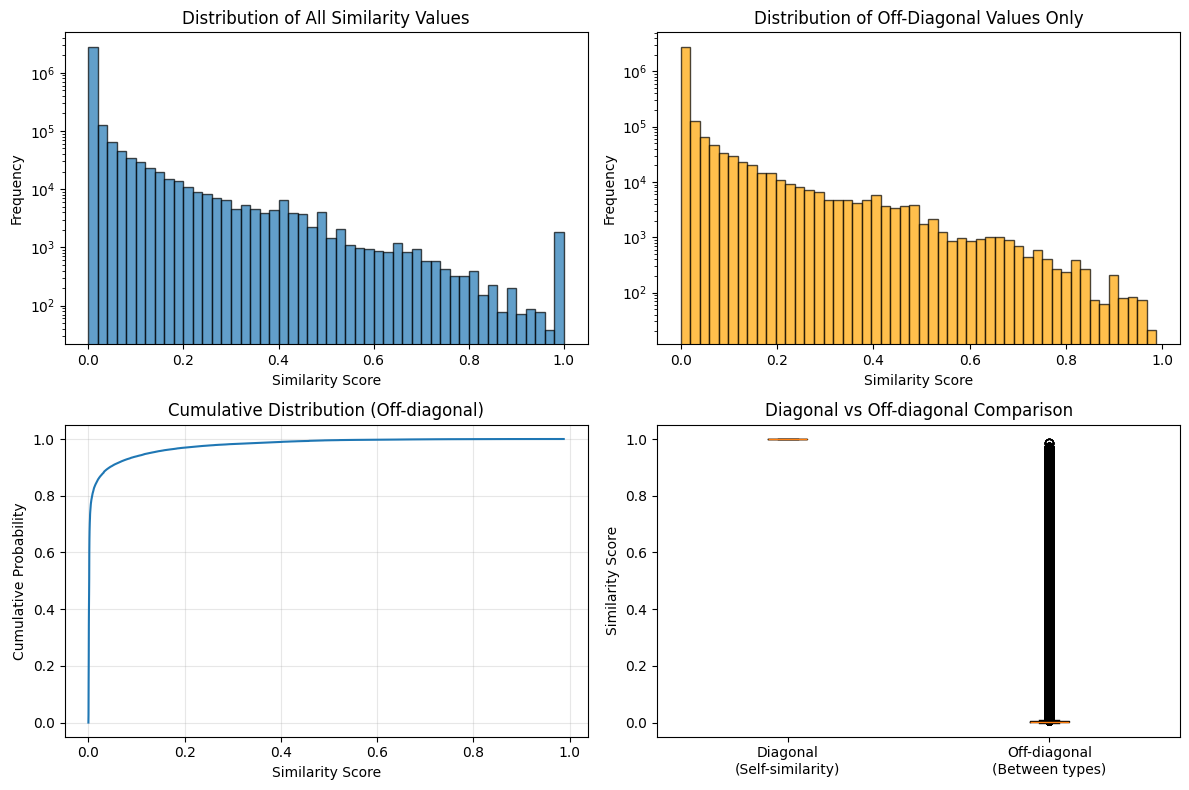

In [12]:
import json
import numpy as np
import networkx as nx
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from collections import Counter

class OntologySimilarityCalculator:
    """Calculate and save PageRank-based similarities between cell types"""

    def __init__(self, alpha=0.9, threshold=1e-4):
        self.alpha = alpha
        self.threshold = threshold
        self.graph = None
        self.cl_id_to_name = {}
        self.name_to_cl_id = {}
        self.similarities = None
        self.similarity_matrix = None  # Store the raw matrix for distribution analysis

    def load_ontology_graph(self, json_file_path):
        """Load ontology graph from JSON file created by OBO parser"""
        with open(json_file_path, 'r') as f:
            data = json.load(f)

        # Create mappings between CL IDs and normalized names
        for cl_id, term_data in data['terms'].items():
            name = self.normalize_cell_type(term_data['name'])
            self.cl_id_to_name[cl_id] = name
            self.name_to_cl_id[name] = cl_id

        # Build NetworkX graph
        edge_list = []
        for child_id, parent_ids in data['graph'].items():
            for parent_id in parent_ids:
                edge_list.append((parent_id, child_id))  # parent -> child

        self.graph = nx.Graph(edge_list)
        print(f"Loaded ontology graph with {len(self.cl_id_to_name)} terms")

    def normalize_cell_type(self, cell_type_name):
        """Normalize cell type name to match extractor normalization"""
        if not cell_type_name:
            return "unknown"

        normalized = cell_type_name.lower().strip()

        # Remove common suffixes - expanded list for better normalization
        suffixes_to_remove = ["cell", "cells", "celltype", "cell type"]
        for suffix in suffixes_to_remove:
            if normalized.endswith(" " + suffix):
                normalized = normalized[:-len(" " + suffix)]
            # Also handle cases where the suffix is at the end without space
            elif normalized.endswith(suffix) and len(normalized) > len(suffix):
                # Check if removing suffix doesn't leave us with empty string
                potential_result = normalized[:-len(suffix)]
                if potential_result.strip():
                    normalized = potential_result

        # Clean up any remaining whitespace
        normalized = normalized.strip()

        # Handle edge case where we might end up with empty string
        if not normalized:
            return "unknown"

        return normalized

    def compute_pagerank_similarities(self):
        """Compute PageRank similarities between all cell types"""
        cl_ids = list(self.cl_id_to_name.keys())
        n_terms = len(cl_ids)
 
        # Create mapping from CL_ID to matrix index
        cl_id_to_idx = {cl_id: i for i, cl_id in enumerate(cl_ids)}
 
        # Initialize similarity matrix
        similarities = np.zeros((n_terms, n_terms), dtype=np.float32)
 
        print("Computing PageRank similarities...")
        for i, source_cl_id in enumerate(tqdm(cl_ids)):
            if source_cl_id not in self.graph:
                continue
 
            # Set personalization vector
            personalization = {cl_id: (cl_id == source_cl_id) for cl_id in cl_ids if cl_id in self.graph}
 
            try:
                # Compute PageRank
                ppr = nx.pagerank(self.graph, alpha=self.alpha, personalization=personalization)
 
                for target_cl_id, score in ppr.items():
                    if target_cl_id in cl_id_to_idx:
                        j = cl_id_to_idx[target_cl_id]
 
                        eps = 1e-12
                        similarities[i, j] = np.log1p(score / self.threshold + eps)
            except Exception as e:
                print(f"Error computing PageRank for {source_cl_id}: {e}")
                continue
 
        # Normalize each row independently to [0,1]
        min_val, max_val = similarities.min(), similarities.max()
        if max_val > min_val:
            similarities = (similarities - min_val) / (max_val - min_val)
 
        # Diagonal as 1.0
        np.fill_diagonal(similarities, 1.0)
 
        # Store the raw similarity matrix for analysis
        self.similarity_matrix = similarities
 
        # Create name-based similarity mapping for easy lookup
        name_similarities = {}
        for i, source_cl_id in enumerate(cl_ids):
            source_name = self.cl_id_to_name[source_cl_id]
            name_similarities[source_name] = {}
            for j, target_cl_id in enumerate(cl_ids):
                target_name = self.cl_id_to_name[target_cl_id]
                name_similarities[source_name][target_name] = float(similarities[i, j])
 
        self.similarities = name_similarities
        print(f"Created similarity matrix with normalized names (examples: {list(name_similarities.keys())[:5]})")
        return name_similarities

    def print_similarity_distribution(self, show_plot=True, bins=50):
        """Analyze and print the distribution of similarity values"""
        if self.similarity_matrix is None:
            raise ValueError("No similarity matrix computed. Run compute_pagerank_similarities first.")
        
        matrix = self.similarity_matrix
        n_terms = matrix.shape[0]
        
        print("=" * 60)
        print("SIMILARITY MATRIX DISTRIBUTION ANALYSIS")
        print("=" * 60)
        
        # Basic statistics
        print(f"Matrix shape: {matrix.shape}")
        print(f"Total number of cell type pairs: {n_terms * n_terms:,}")
        print(f"Total unique pairs (including diagonal): {n_terms * n_terms:,}")
        
        # Get all values (entire matrix)
        all_values = matrix.flatten()
        
        print(f"\nBASIC STATISTICS:")
        print(f"Min value: {all_values.min():.6f}")
        print(f"Max value: {all_values.max():.6f}")
        print(f"Mean: {all_values.mean():.6f}")
        print(f"Median: {np.median(all_values):.6f}")
        print(f"Standard deviation: {all_values.std():.6f}")
        
        # Percentile analysis
        percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
        print(f"\nPERCENTILE ANALYSIS:")
        for p in percentiles:
            value = np.percentile(all_values, p)
            print(f"{p:2d}th percentile: {value:.6f}")
        
        # Count values in different ranges
        ranges = [
            (0.0, 0.1, "Very low similarity"),
            (0.1, 0.3, "Low similarity"),
            (0.3, 0.5, "Medium similarity"),
            (0.5, 0.7, "High similarity"),
            (0.7, 0.9, "Very high similarity"),
            (0.9, 1.0, "Extremely high similarity"),
            (1.0, 1.0, "Perfect similarity (diagonal)")
        ]
        
        print(f"\nSIMILARITY RANGE DISTRIBUTION:")
        total_values = len(all_values)
        
        for min_val, max_val, description in ranges:
            if min_val == max_val:  # Special case for perfect similarity
                count = np.sum(all_values == min_val)
            else:
                count = np.sum((all_values >= min_val) & (all_values < max_val))
            
            percentage = (count / total_values) * 100
            print(f"{description:<30}: {count:8,} ({percentage:5.1f}%)")
        
        # Analyze diagonal vs off-diagonal
        diagonal_values = np.diag(matrix)
        off_diagonal_mask = ~np.eye(n_terms, dtype=bool)
        off_diagonal_values = matrix[off_diagonal_mask]
        
        print(f"\nDIAGONAL vs OFF-DIAGONAL ANALYSIS:")
        print(f"Diagonal values (self-similarity):")
        print(f"  Count: {len(diagonal_values):,}")
        print(f"  Min: {diagonal_values.min():.6f}")
        print(f"  Max: {diagonal_values.max():.6f}")
        print(f"  Mean: {diagonal_values.mean():.6f}")
        
        print(f"Off-diagonal values (between different cell types):")
        print(f"  Count: {len(off_diagonal_values):,}")
        print(f"  Min: {off_diagonal_values.min():.6f}")
        print(f"  Max: {off_diagonal_values.max():.6f}")
        print(f"  Mean: {off_diagonal_values.mean():.6f}")
        print(f"  Median: {np.median(off_diagonal_values):.6f}")
        
        # Find most and least similar pairs (excluding diagonal)
        print(f"\nTOP 10 MOST SIMILAR CELL TYPE PAIRS (excluding self):")
        # Get indices of upper triangle (excluding diagonal) to avoid duplicates
        upper_triangle_indices = np.triu_indices(n_terms, k=1)
        upper_triangle_values = matrix[upper_triangle_indices]
        
        # Get top similarities
        top_indices = np.argsort(upper_triangle_values)[-10:][::-1]  # Top 10, descending
        
        cl_ids = list(self.cl_id_to_name.keys())
        for rank, idx in enumerate(top_indices, 1):
            original_i, original_j = upper_triangle_indices[0][idx], upper_triangle_indices[1][idx]
            similarity_score = upper_triangle_values[idx]
            name1 = self.cl_id_to_name[cl_ids[original_i]]
            name2 = self.cl_id_to_name[cl_ids[original_j]]
            print(f"{rank:2d}. {name1:<25} ↔ {name2:<25} ({similarity_score:.4f})")
        
        # Sparsity analysis
        zero_threshold = 1e-6
        near_zero_count = np.sum(off_diagonal_values < zero_threshold)
        sparsity = (near_zero_count / len(off_diagonal_values)) * 100
        print(f"\nSPARSITY ANALYSIS:")
        print(f"Values < {zero_threshold} (essentially zero): {near_zero_count:,} ({sparsity:.1f}%)")
        
        # Create histogram plot if requested
        if show_plot:
            try:
                plt.figure(figsize=(12, 8))
                
                # Plot 1: Distribution of all values
                plt.subplot(2, 2, 1)
                plt.hist(all_values, bins=bins, alpha=0.7, edgecolor='black')
                plt.xlabel('Similarity Score')
                plt.ylabel('Frequency')
                plt.title('Distribution of All Similarity Values')
                plt.yscale('log')
                
                # Plot 2: Distribution of off-diagonal values only
                plt.subplot(2, 2, 2)
                plt.hist(off_diagonal_values, bins=bins, alpha=0.7, color='orange', edgecolor='black')
                plt.xlabel('Similarity Score')
                plt.ylabel('Frequency')
                plt.title('Distribution of Off-Diagonal Values Only')
                plt.yscale('log')
                
                # Plot 3: Cumulative distribution
                plt.subplot(2, 2, 3)
                sorted_values = np.sort(off_diagonal_values)
                cumulative = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
                plt.plot(sorted_values, cumulative)
                plt.xlabel('Similarity Score')
                plt.ylabel('Cumulative Probability')
                plt.title('Cumulative Distribution (Off-diagonal)')
                plt.grid(True, alpha=0.3)
                
                # Plot 4: Box plot comparison
                plt.subplot(2, 2, 4)
                plt.boxplot([diagonal_values, off_diagonal_values], 
                           labels=['Diagonal\n(Self-similarity)', 'Off-diagonal\n(Between types)'])
                plt.ylabel('Similarity Score')
                plt.title('Diagonal vs Off-diagonal Comparison')
                
                plt.tight_layout()
                plt.show()
                
            except ImportError:
                print("\nNote: matplotlib not available for plotting. Install with: pip install matplotlib")
        
        print("=" * 60)
        
        return {
            'matrix_shape': matrix.shape,
            'all_values_stats': {
                'min': float(all_values.min()),
                'max': float(all_values.max()),
                'mean': float(all_values.mean()),
                'median': float(np.median(all_values)),
                'std': float(all_values.std())
            },
            'off_diagonal_stats': {
                'min': float(off_diagonal_values.min()),
                'max': float(off_diagonal_values.max()),
                'mean': float(off_diagonal_values.mean()),
                'median': float(np.median(off_diagonal_values)),
                'std': float(off_diagonal_values.std())
            },
            'sparsity_percent': float(sparsity)
        }

    def save_similarities(self, output_path):
        """Save computed similarities to file"""
        if self.similarities is None:
            raise ValueError("No similarities computed. Run compute_pagerank_similarities first.")

        with open(output_path, 'wb') as f:
            pickle.dump(self.similarities, f)

        print(f"Saved similarities to {output_path}")
        print(f"Matrix contains {len(self.similarities)} cell types")

    def load_similarities(self, similarity_file_path):
        """Load precomputed similarities"""
        with open(similarity_file_path, 'rb') as f:
            self.similarities = pickle.load(f)
        return self.similarities

    def get_similarity(self, cell_type1, cell_type2):
        """Get similarity between two cell types (both should be normalized names)"""
        if self.similarities is None:
            raise ValueError("No similarities loaded. Run compute_pagerank_similarities or load_similarities first.")

        # Normalize the input names in case they weren't already
        norm_type1 = self.normalize_cell_type(cell_type1)
        norm_type2 = self.normalize_cell_type(cell_type2)

        return self.similarities.get(norm_type1, {}).get(norm_type2, 0.0)

    def print_sample_similarities(self, cell_type_name, top_k=10):
        """Print top similar cell types for a given cell type"""
        if self.similarities is None:
            raise ValueError("No similarities loaded.")

        norm_name = self.normalize_cell_type(cell_type_name)

        if norm_name not in self.similarities:
            print(f"Cell type '{norm_name}' not found in similarities.")
            available = list(self.similarities.keys())[:10]
            print(f"Available cell types (first 10): {available}")
            return

        # Get similarities for this cell type and sort by score
        sims = self.similarities[norm_name]
        sorted_sims = sorted(sims.items(), key=lambda x: x[1], reverse=True)

        print(f"Top {top_k} similar cell types to '{norm_name}':")
        for i, (target_name, score) in enumerate(sorted_sims[:top_k]):
            print(f"  {i+1:2d}. {target_name:<30} (similarity: {score:.4f})")


def create_similarity_file(obo_json_path, output_similarity_path, analyze_distribution=True):
    """Helper function to create similarity file from OBO JSON"""
    calculator = OntologySimilarityCalculator()
    calculator.load_ontology_graph(obo_json_path)
    calculator.compute_pagerank_similarities()
    
    # Analyze distribution before saving
    if analyze_distribution:
        distribution_stats = calculator.print_similarity_distribution(show_plot=False)
        
    calculator.save_similarities(output_similarity_path)

    # Show some examples of the normalized names
    sample_names = list(calculator.similarities.keys())[:10]
    print(f"Sample normalized cell type names: {sample_names}")

    return calculator


# Example usage:
if __name__ == "__main__":
    # Step 1: Create similarity file and analyze distribution
    calculator = create_similarity_file("tissue_human_graph.json", "/home/arism/datasets/tissue_similarities.pkl")

    # Step 2: Test the similarity lookup
    calculator.print_sample_similarities("T helper cell", top_k=5)
    
    # Step 3: Print detailed distribution analysis
    print("\n" + "="*80)
    print("DETAILED DISTRIBUTION ANALYSIS")
    print("="*80)
    distribution_stats = calculator.print_similarity_distribution(show_plot=True)